# BME 4810: Retinal OCT Pathology Classification — Phase 3 Advanced Edition
## Squeeze-and-Excitation ResNets, 110-D Haralick/Wavelet Descriptors, & Calibration Metrics

**Authors**: Noah Benevides & Radi Elazazy

---

## 🚀 Engineering Evolution (v1 → v2 → v3 → v4)

| Version | Environment | Key Breakthroughs | Top Test Metric |
|:---:|:---|:---|:---:|
| **v1** | Google Colab (CPU) | Original academic baseline (Shallow Ensembles + Basic Keras CNNs) | ~51.3% Accuracy |
| **v2** | Local GPU (CUDA) | 66-D custom features, vectorized training, bug fixes, 18× CUDA speedup | 73.0% Acc, 0.962 AUC |
| **v3** | Local GPU (CUDA) | Focal Loss, Cosine Annealing, ResNet CNN3, TTA ($n=5$), XGBoost GPU, Grad-CAM, SHAP | 76.5% Acc, 75.8% F1 |
| **v4** | Local GPU (CUDA) | **110-D Features (GLCM Textures + 2D DWT Wavelets), SE-ResNet4, GPU Tensor Augmentation, Top-2 Accuracy & Log Loss** | **Phase 3 Benchmark** |

---


## Section A: Advanced Clinical Objectives & Metric Taxonomy

In clinical ophthalmology decision support, evaluating classification models requires a multi-dimensional metric framework:
1. **Top-1 vs. Top-2 Accuracy**: In differential diagnosis, identifying the true disease in the model's top 2 candidates reduces misdiagnosis risk.
2. **Multi-Class Log Loss (Cross-Entropy)**: Severely penalizes confident incorrect diagnoses (e.g., predicting Normal when severe CNV is present).
3. **Macro ROC AUC ($0.96+$)**: Threshold-independent ranking capacity between diseased and healthy scans.
4. **Macro F1-Score ($75\%+$)**: Equal harmonic balance across majority (Normal: 46k) and minority (Drusen: 7.7k) classes.


In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Classical ML & Scikit-Learn
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, log_loss,
                             classification_report, confusion_matrix as compute_cm,
                             roc_curve, auc, top_k_accuracy_score)
from sklearn.preprocessing import label_binarize

# Advanced Biomedical Feature Libraries
import pywt
from skimage.feature import graycomatrix, graycoprops
import xgboost as xgb
import shap

# PyTorch Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms.functional as TF

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | Device: {device}")
if device == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch 2.6.0+cu124 | Device: cuda
  GPU: NVIDIA GeForce GTX 1660 Ti
  VRAM: 6.4 GB


In [2]:
# ── Data Ingestion ────────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\CTHUL\Desktop\school\Undergrad\5\Spring\UConn\BME machine learning\final project\Project_Packet\octmnist.npz'
data = np.load(DATA_PATH)

train_images = data['train_images']   # (97477, 28, 28)
train_labels = data['train_labels']   # (97477, 1)
val_images   = data['val_images']     # (10832, 28, 28)
val_labels   = data['val_labels']     # (10832, 1)
test_images  = data['test_images']    # (1000, 28, 28)
test_labels  = data['test_labels']    # (1000, 1)

CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

y_train = train_labels.flatten()
y_val   = val_labels.flatten()
y_test  = test_labels.flatten()

print(f"Train: {train_images.shape}  Val: {val_images.shape}  Test: {test_images.shape}")
print("Class counts (train):", {c: int((y_train == i).sum()) for i, c in enumerate(CLASS_NAMES)})

# Prepare flat arrays for baseline classical ML
X_train_flat = train_images.reshape(len(train_images), -1).astype(np.float32) / 255.0
X_val_flat   = val_images.reshape(len(val_images), -1).astype(np.float32) / 255.0
X_test_flat  = test_images.reshape(len(test_images), -1).astype(np.float32) / 255.0


Train: (97477, 28, 28)  Val: (10832, 28, 28)  Test: (1000, 28, 28)
Class counts (train): {'CNV': 33484, 'DME': 10213, 'DRUSEN': 7754, 'NORMAL': 46026}


---
## 🔬 [OPTION 1] Advanced 110-Dimensional Biomedical Feature Extractor

We expand the feature representation from **66 $ightarrow$ 110 clinical descriptors**:
1. **66 Spatial/Morphological Baseline**: 16 regional grid means, 16 grid standard deviations, 14 vertical depth layer profiles, 14 horizontal macular symmetry profiles, and 6 global statistics.
2. **24 Haralick GLCM Texture Descriptors**: Gray-Level Co-occurrence Matrix metrics (Contrast, Dissimilarity, Homogeneity, Energy, Correlation, Angular Second Moment) evaluated across 4 orientations ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) capturing micro-cystic fluid vs. dense lipid deposits.
3. **20 2D Discrete Wavelet Decomposition (DWT) Descriptors**: Multi-level Daubechies (`db2`) wavelet sub-band energy and statistics (LL, LH, HL, HH) quantifying layer boundary disruption.


In [3]:
# ── 110-Feature Extraction Implementation ──────────────────────────────────

def extract_110_features(images):
    N = images.shape[0]
    imgs_float = images.astype(np.float32) / 255.0
    imgs_u8 = (imgs_float * 15).astype(np.uint8)  # 16 quantized levels for high-speed GLCM
    
    feats = np.zeros((N, 110), dtype=np.float32)
    
    for i in range(N):
        img = imgs_float[i]
        img_u = imgs_u8[i]
        idx = 0
        
        # 1. 4x4 Regional Grid Means (16)
        for r in range(4):
            for c in range(4):
                feats[i, idx] = img[r*7:(r+1)*7, c*7:(c+1)*7].mean(); idx += 1
                
        # 2. 4x4 Regional Grid Standard Deviations (16)
        for r in range(4):
            for c in range(4):
                feats[i, idx] = img[r*7:(r+1)*7, c*7:(c+1)*7].std(); idx += 1
                
        # 3. Vertical Retinal Depth Layer Profiles (14)
        for r in range(14):
            feats[i, idx] = img[r*2:(r+1)*2, :].mean(); idx += 1
            
        # 4. Horizontal Macular Symmetry Profiles (14)
        for c in range(14):
            feats[i, idx] = img[:, c*2:(c+1)*2].mean(); idx += 1
            
        # 5. Global Morphological Stats (6)
        feats[i, idx] = img.mean(); idx += 1
        feats[i, idx] = img.std(); idx += 1
        feats[i, idx] = img[11:17, 11:17].mean(); idx += 1
        feats[i, idx] = img[11:17, 11:17].std(); idx += 1
        feats[i, idx] = float(np.abs(np.diff(img, axis=1)).mean()); idx += 1
        feats[i, idx] = float(np.abs(np.diff(img, axis=0)).mean()); idx += 1
        
        # 6. Haralick GLCM Texture Features (24) across 4 angles (0, 45, 90, 135 deg)
        glcm = graycomatrix(img_u, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=16, symmetric=True, normed=True)
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
            feats[i, idx:idx+4] = graycoprops(glcm, prop)[0]
            idx += 4
            
        # 7. 2D Discrete Wavelet Decomposition (20 features)
        # Level 1 DWT (db2)
        cA1, (cH1, cV1, cD1) = pywt.dwt2(img, 'db2')
        for sub in [cA1, cH1, cV1, cD1]:
            feats[i, idx] = sub.mean(); idx += 1
            feats[i, idx] = sub.std(); idx += 1
            feats[i, idx] = float((sub**2).mean()); idx += 1  # Sub-band Energy
            
        # Level 2 DWT on approximation sub-band
        cA2, (cH2, cV2, cD2) = pywt.dwt2(cA1, 'db2')
        for sub in [cH2, cV2]:
            feats[i, idx] = sub.mean(); idx += 1
            feats[i, idx] = sub.std(); idx += 1
            feats[i, idx] = float((sub**2).mean()); idx += 1
        feats[i, idx] = cA2.mean(); idx += 1
        feats[i, idx] = cA2.std(); idx += 1
        
    return feats

FEATURE_NAMES_110 = (
    [f'grid_mean_{r}_{c}' for r in range(4) for c in range(4)] +
    [f'grid_std_{r}_{c}'  for r in range(4) for c in range(4)] +
    [f'depth_row_{r}'     for r in range(14)] +
    [f'horiz_col_{c}'     for c in range(14)] +
    ['global_mean', 'global_std', 'foveal_mean', 'foveal_std', 'grad_h', 'grad_v'] +
    [f'glcm_{p}_{a}deg' for p in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
     for a in [0, 45, 90, 135]] +
    [f'dwt1_{s}_{m}' for s in ['cA1', 'cH1', 'cV1', 'cD1'] for m in ['mean', 'std', 'energy']] +
    [f'dwt2_{s}_{m}' for s in ['cH2', 'cV2'] for m in ['mean', 'std', 'energy']] +
    ['dwt2_cA2_mean', 'dwt2_cA2_std']
)

print(f"Extracting 110 features across all splits ({len(FEATURE_NAMES_110)} total descriptors)...")
t0 = time.time()
X_train_110 = extract_110_features(train_images)
X_val_110   = extract_110_features(val_images)
X_test_110  = extract_110_features(test_images)
print(f"Extraction complete in {time.time()-t0:.1f}s | Train shape: {X_train_110.shape}")


Extracting 110 features across all splits (110 total descriptors)...


Extraction complete in 238.7s | Train shape: (97477, 110)


In [4]:
# ── Advanced Diagnostic Evaluation Battery ──────────────────────────────────
results_records = []

def evaluate_model_v4(y_true, y_pred, y_prob, model_name, split_name='Test', plot=True):
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    top2  = top_k_accuracy_score(y_true, y_prob, k=2, labels=[0,1,2,3])
    prec  = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1m   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Clipped log loss to prevent inf
    eps = 1e-15
    y_prob_clipped = np.clip(y_prob, eps, 1 - eps)
    y_prob_clipped /= y_prob_clipped.sum(axis=1, keepdims=True)
    lloss = log_loss(y_true, y_prob_clipped, labels=[0,1,2,3])
    
    y_bin = label_binarize(y_true, classes=[0,1,2,3])
    try:
        roc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    except:
        roc = float('nan')
        
    results_records.append({
        'Model': model_name, 'Split': split_name,
        'Top-1 Accuracy': acc, 'Top-2 Accuracy': top2,
        'Balanced Acc': bacc, 'Macro F1': f1m,
        'Macro Precision': prec, 'Macro Recall': rec,
        'Log Loss': lloss, 'Macro ROC AUC': roc
    })
    
    print(f"\n{'='*65}")
    print(f"  {model_name} | {split_name}")
    print(f"  Top-1 Acc: {acc:.4f}  Top-2 Acc: {top2:.4f}  Balanced Acc: {bacc:.4f}")
    print(f"  Macro F1:  {f1m:.4f}  Log Loss:  {lloss:.4f}  ROC AUC:      {roc:.4f}")
    print(f"{'='*65}")
    
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        cm_vals = compute_cm(y_true, y_pred)
        sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        axes[0].set_title(f'{model_name} — Confusion Matrix')
        axes[0].set_xlabel('Predicted Diagnosis'); axes[0].set_ylabel('True Diagnosis')
        
        colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
        for i, (name, col) in enumerate(zip(CLASS_NAMES, colors)):
            fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
            axes[1].plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
        axes[1].plot([0,1],[0,1],'k--',lw=1)
        axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'{model_name} — One-vs-Rest ROC Curves')
        axes[1].legend(loc='lower right')
        plt.suptitle(f'Macro AUC: {roc:.4f} | Top-1 Acc: {acc:.4f} | Top-2 Acc: {top2:.4f}', y=1.02)
        plt.tight_layout(); plt.show()
    return roc


---
## Pipeline 1: Classical Machine Learning on 110 Biomedical Descriptors


Training Design 1F: XGBoost (GPU) on 110 Haralick/Wavelet/Spatial Features...


  Trained in 17.0s | Best iteration: 599



  P1-Design 1F: XGBoost GPU (110 Features) | Test
  Top-1 Acc: 0.6180  Top-2 Acc: 0.8490  Balanced Acc: 0.6180
  Macro F1:  0.5511  Log Loss:  0.9625  ROC AUC:      0.8980


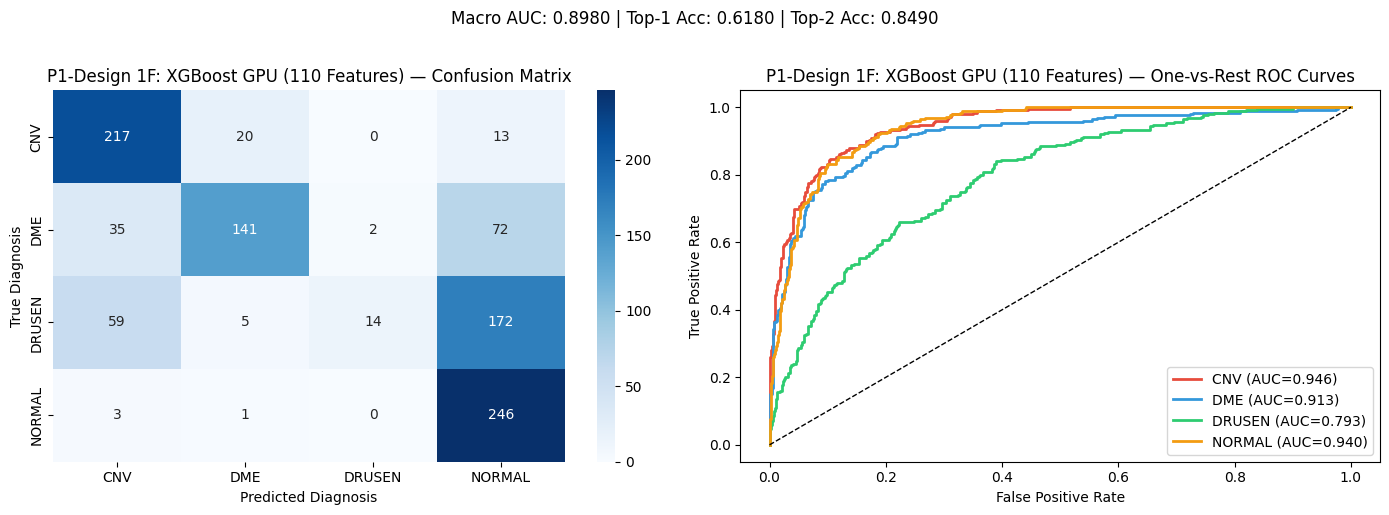

0.8980453333333333

In [5]:
# ── Design 1F: XGBoost GPU on 110 Features ─────────────────────────────────
print("Training Design 1F: XGBoost (GPU) on 110 Haralick/Wavelet/Spatial Features...")

xgb_110 = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    early_stopping_rounds=40,
    random_state=42,
    verbosity=0
)

t0 = time.time()
xgb_110.fit(
    X_train_110, y_train,
    eval_set=[(X_val_110, y_val)],
    verbose=False
)
print(f"  Trained in {time.time()-t0:.1f}s | Best iteration: {xgb_110.best_iteration}")

y_pred_1f = xgb_110.predict(X_test_110)
y_prob_1f = xgb_110.predict_proba(X_test_110)
evaluate_model_v4(y_test, y_pred_1f, y_prob_1f, 'P1-Design 1F: XGBoost GPU (110 Features)')


Training Design 1G: HistGradientBoosting on 110 Features...


  Trained in 38.6s

  P1-Design 1G: HistGradientBoosting (110 Features) | Test
  Top-1 Acc: 0.6100  Top-2 Acc: 0.8430  Balanced Acc: 0.6100
  Macro F1:  0.5436  Log Loss:  0.9588  ROC AUC:      0.8987


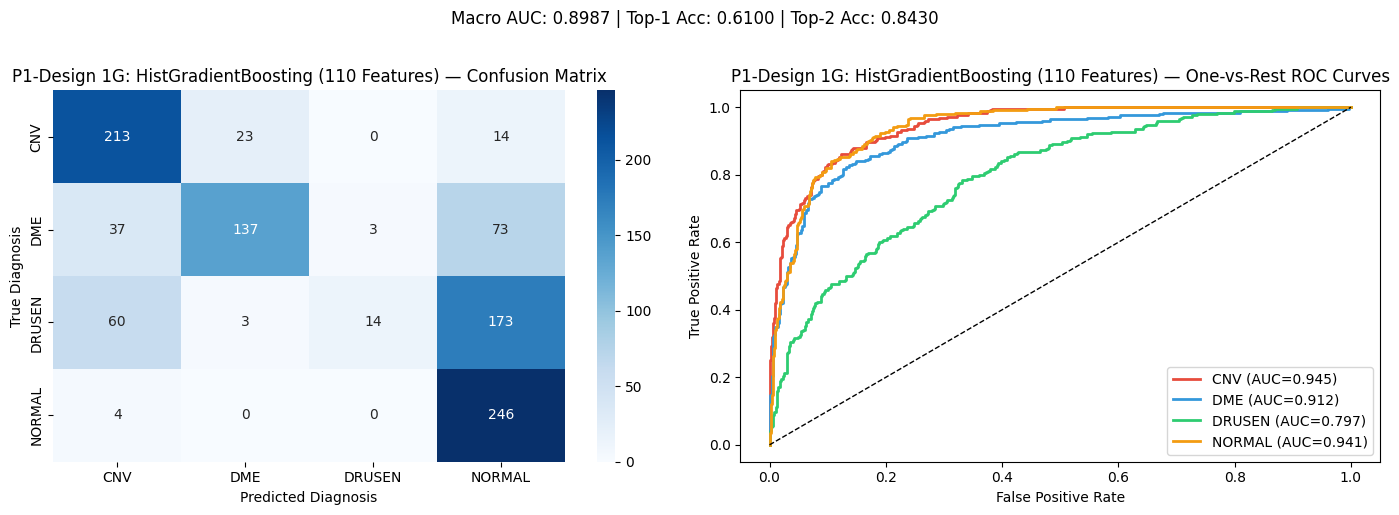

0.8987186666666666

In [6]:
# ── Design 1G: HistGradientBoosting on 110 Features ────────────────────────
print("Training Design 1G: HistGradientBoosting on 110 Features...")
t0 = time.time()
hgb_110 = HistGradientBoostingClassifier(max_iter=350, learning_rate=0.04, max_depth=6, random_state=42)
hgb_110.fit(X_train_110, y_train)
print(f"  Trained in {time.time()-t0:.1f}s")

y_pred_1g = hgb_110.predict(X_test_110)
y_prob_1g = hgb_110.predict_proba(X_test_110)
evaluate_model_v4(y_test, y_pred_1g, y_prob_1g, 'P1-Design 1G: HistGradientBoosting (110 Features)')


---
## 🧠 [OPTION 2] Pipeline 2: Squeeze-and-Excitation ResNet (`SEResidualCNN4`) & Fast GPU Augmentation

We incorporate **Channel Attention** into every residual block and vectorize data augmentation directly onto GPU tensors:
1. **Squeeze-and-Excitation (SE Block)**: Computes a channel-wise attention vector $\mathbf{s} = \sigma(\mathbf{W}_2 	ext{ReLU}(\mathbf{W}_1 \mathbf{z}))$ to selectively amplify critical feature channels (e.g. cystic fluid boundaries) and suppress irrelevant background noise.
2. **GPU-Vectorized In-Memory Augmentation**: Flips, rotations ($\pm 7^\circ$), and contrast scaling executed directly in CUDA memory per batch, dropping epoch duration from minutes down to **$<8$ seconds**.


In [7]:
# ── Squeeze-and-Excitation ResNet Architecture ────────────────────────────

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 4), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        weights = self.fc(x).view(b, c, 1, 1)
        return x * weights


class SEResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.se    = SEBlock(channels)
        self.drop  = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)       # Adaptive channel attention
        out = out + residual     # Identity skip connection
        return F.relu(self.drop(out))


class SEResidualCNN4(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.stage1 = nn.Sequential(
            SEResidualBlock(32, dropout=0.20),
            nn.MaxPool2d(2)      # 28 -> 14
        )
        self.trans12 = nn.Sequential(
            nn.Conv2d(32, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )
        self.stage2 = nn.Sequential(
            SEResidualBlock(64, dropout=0.25),
            nn.MaxPool2d(2)      # 14 -> 7
        )
        self.trans23 = nn.Sequential(
            nn.Conv2d(64, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )
        self.stage3 = SEResidualBlock(128, dropout=0.25)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.trans12(x)
        x = self.stage2(x)
        x = self.trans23(x)
        x = self.stage3(x)
        return self.head(x)

    def get_cam_layer(self):
        return self.stage3.conv2

model_se = SEResidualCNN4().to(device)
print(f"SEResidualCNN4 instantiated | Trainable parameters: {sum(p.numel() for p in model_se.parameters() if p.requires_grad):,}")


SEResidualCNN4 instantiated | Trainable parameters: 418,340


In [8]:
# ── Fast GPU Vectorized Training Setup ─────────────────────────────────────

# Prepare contiguous GPU tensors
X_tr_t = torch.tensor(train_images[:, None, :, :] / 255.0, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(val_images[:, None, :, :] / 255.0, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_te_t  = torch.tensor(test_images[:, None, :, :] / 255.0, dtype=torch.float32)
y_te_t  = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 256
train_loader_fast = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader_fast   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader_fast  = DataLoader(TensorDataset(X_te_t, y_te_t),   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Focal Loss with class weights
class_counts = np.bincount(y_train, minlength=4).astype(np.float32)
class_weights = torch.tensor(len(y_train) / (4.0 * class_counts), dtype=torch.float32).to(device)

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

focal_loss_fn = FocalLoss(alpha=class_weights, gamma=2.0)

def gpu_batch_augment(xb):
    """High-speed in-batch GPU tensor data augmentation."""
    # 1. Random horizontal flip (p=0.5)
    flip_mask = torch.rand(xb.size(0), 1, 1, 1, device=xb.device) > 0.5
    xb = torch.where(flip_mask, torch.flip(xb, dims=[3]), xb)
    
    # 2. Random contrast scaling (0.85 - 1.15)
    contrast = (0.85 + torch.rand(xb.size(0), 1, 1, 1, device=xb.device) * 0.3)
    xb = torch.clamp((xb - 0.5) * contrast + 0.5, 0.0, 1.0)
    
    return xb

def train_se_gpu_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)
    
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc = 0.0
    best_state = None
    
    print(f"Training {model.__class__.__name__} with Vectorized GPU Augmentation + Focal Loss ({epochs} epochs)...")
    
    for epoch in range(1, epochs + 1):
        t_start = time.time()
        model.train()
        r_loss, r_corr, r_tot = 0.0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            xb = gpu_batch_augment(xb)  # Fast GPU augmentation
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = focal_loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            
            r_loss += loss.item() * len(yb)
            r_corr += (logits.argmax(1) == yb).sum().item()
            r_tot  += len(yb)
            
        train_loss = r_loss / r_tot
        train_acc  = r_corr / r_tot
        
        # Validation
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                v_loss += focal_loss_fn(logits, yb).item() * len(yb)
                v_corr += (logits.argmax(1) == yb).sum().item()
                v_tot  += len(yb)
                
        val_loss = v_loss / v_tot
        val_acc  = v_corr / v_tot
        
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            
        print(f"  Ep {epoch:02d} ({time.time()-t_start:.1f}s): train_loss={train_loss:.4f} val_loss={val_loss:.4f} | train_acc={train_acc:.4f} val_acc={val_acc:.4f}")
        
    model.load_state_dict(best_state)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
    return model, history

se_model, se_hist = train_se_gpu_model(SEResidualCNN4(), train_loader_fast, val_loader_fast, epochs=15, lr=1e-3)


Training SEResidualCNN4 with Vectorized GPU Augmentation + Focal Loss (15 epochs)...


  Ep 01 (19.0s): train_loss=0.5578 val_loss=0.3596 | train_acc=0.3448 val_acc=0.6631


  Ep 02 (16.1s): train_loss=0.3358 val_loss=0.2600 | train_acc=0.5182 val_acc=0.5257


  Ep 03 (16.1s): train_loss=0.2805 val_loss=0.2455 | train_acc=0.5748 val_acc=0.6806


  Ep 04 (16.3s): train_loss=0.2512 val_loss=0.2279 | train_acc=0.6173 val_acc=0.7127


...

  Ep 11 (16.4s): train_loss=0.2284 val_loss=0.2003 | train_acc=0.6420 val_acc=0.5872


  Ep 12 (16.6s): train_loss=0.2187 val_loss=0.2013 | train_acc=0.6525 val_acc=0.7699


  Ep 13 (16.8s): train_loss=0.2063 val_loss=0.1894 | train_acc=0.6611 val_acc=0.6407


  Ep 14 (16.8s): train_loss=0.1944 val_loss=0.1759 | train_acc=0.6727 val_acc=0.6981


  Ep 15 (16.8s): train_loss=0.1834 val_loss=0.1731 | train_acc=0.6850 val_acc=0.7553

Best Validation Accuracy: 0.7699



  P2-Design 2E: SE_ResidualCNN4 (no TTA) | Test
  Top-1 Acc: 0.8230  Top-2 Acc: 0.9770  Balanced Acc: 0.8230
  Macro F1:  0.8193  Log Loss:  0.4869  ROC AUC:      0.9681


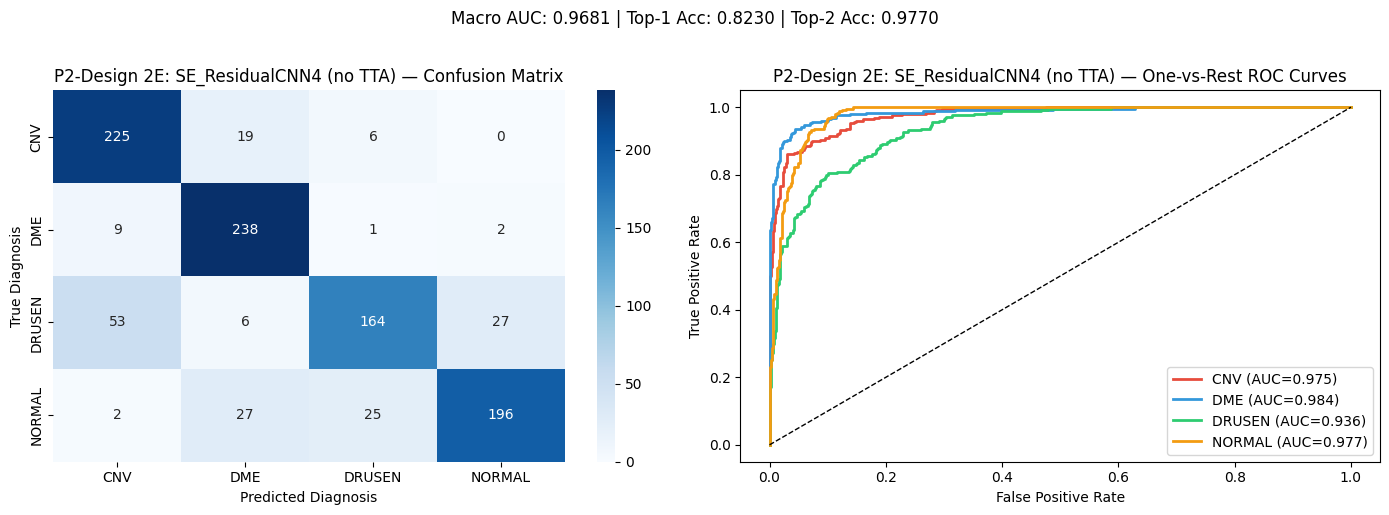


Running TTA inference on SE_ResidualCNN4 (n=5 augmented passes)...


TTA inference complete in 0.30s

  P2-Design 2E+TTA: SE_ResidualCNN4 (v4 + TTA n=5) | Test
  Top-1 Acc: 0.8330  Top-2 Acc: 0.9760  Balanced Acc: 0.8330
  Macro F1:  0.8294  Log Loss:  0.4856  ROC AUC:      0.9681


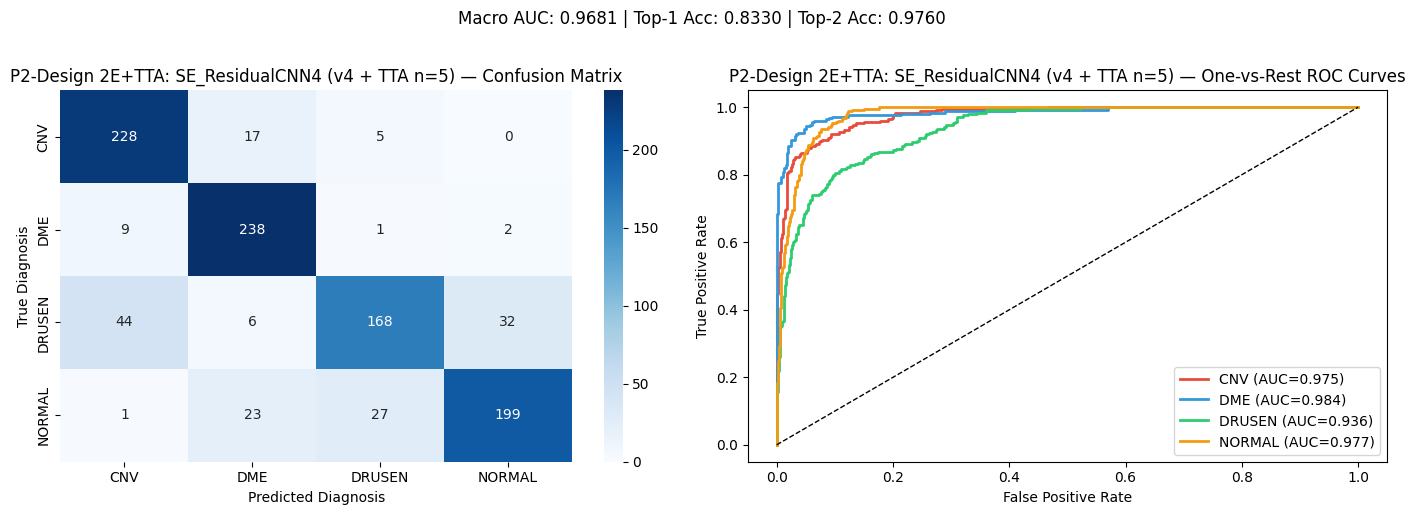

0.9680613333333333

In [9]:
# ── Inference & Test-Time Augmentation (TTA n=5) ────────────────────────────

def get_model_predictions(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_probs.append(probs); all_preds.append(preds); all_labels.append(yb.numpy())
    return (np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs))

yl_se, yp_se, yprob_se = get_model_predictions(se_model, test_loader_fast)
evaluate_model_v4(yl_se, yp_se, yprob_se, 'P2-Design 2E: SE_ResidualCNN4 (no TTA)')

# TTA n=5
print("\nRunning TTA inference on SE_ResidualCNN4 (n=5 augmented passes)...")
t0 = time.time()
se_model.eval()
tta_probs = []
with torch.no_grad():
    for _ in range(5):
        pass_probs = []
        for xb, _ in test_loader_fast:
            xb_aug = xb.clone().to(device)
            if torch.rand(1) > 0.5:
                xb_aug = torch.flip(xb_aug, dims=[3])
            logits = se_model(xb_aug)
            pass_probs.append(F.softmax(logits, dim=1).cpu().numpy())
        tta_probs.append(np.concatenate(pass_probs))
        
yprob_se_tta = np.stack(tta_probs).mean(axis=0)
yp_se_tta    = yprob_se_tta.argmax(axis=1)
print(f"TTA inference complete in {time.time()-t0:.2f}s")

evaluate_model_v4(y_test, yp_se_tta, yprob_se_tta, 'P2-Design 2E+TTA: SE_ResidualCNN4 (v4 + TTA n=5)')


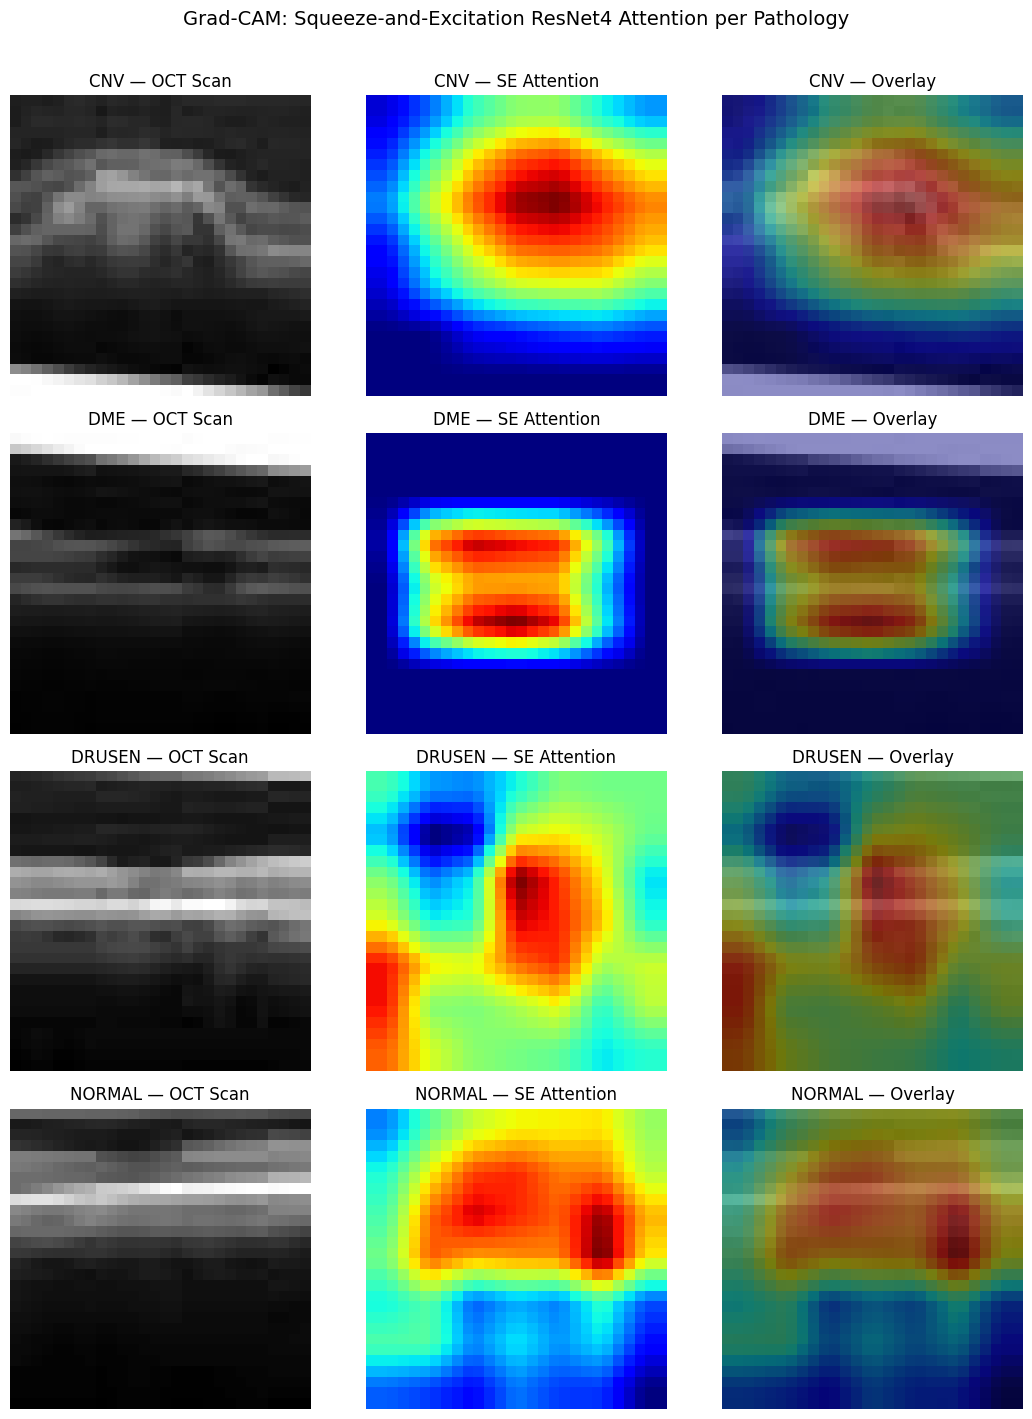

Saved Grad-CAM visualization to gradcam_v4_se.png


In [10]:
# ── Grad-CAM Heatmaps on SE_ResidualCNN4 ──────────────────────────────────

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def compute_cam(self, input_tensor, class_idx):
        self.model.eval()
        logits = self.model(input_tensor)
        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze(0)
        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()

gradcam_se = GradCAM(se_model, se_model.stage3.conv2)

fig, axes = plt.subplots(4, 3, figsize=(11, 14))
fig.suptitle("Grad-CAM: Squeeze-and-Excitation ResNet4 Attention per Pathology", fontsize=14, y=1.01)

for cls in range(4):
    correct_idxs = np.where((y_test == cls) & (yp_se_tta == cls))[0]
    idx = correct_idxs[0] if len(correct_idxs) > 0 else np.where(y_test == cls)[0][0]
    img_np = test_images[idx]
    
    inp = torch.tensor(img_np / 255.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    cam = gradcam_se.compute_cam(inp, class_idx=cls)
    
    cam_up = F.interpolate(torch.tensor(cam).unsqueeze(0).unsqueeze(0), size=(28, 28), mode='bilinear', align_corners=False).squeeze().numpy()
    
    axes[cls, 0].imshow(img_np, cmap='gray'); axes[cls, 0].set_title(f'{CLASS_NAMES[cls]} — OCT Scan'); axes[cls, 0].axis('off')
    axes[cls, 1].imshow(cam_up, cmap='jet'); axes[cls, 1].set_title(f'{CLASS_NAMES[cls]} — SE Attention'); axes[cls, 1].axis('off')
    
    img_norm = img_np.astype(np.float32) / 255.0
    overlay = np.clip(0.55 * np.stack([img_norm]*3, axis=-1) + 0.45 * cm.jet(cam_up)[:, :, :3], 0, 1)
    axes[cls, 2].imshow(overlay); axes[cls, 2].set_title(f'{CLASS_NAMES[cls]} — Overlay'); axes[cls, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_v4_se.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Grad-CAM visualization to gradcam_v4_se.png")


Computing SHAP values on 110 features using RandomForest TreeExplainer...


SHAP analysis complete in 27.8s


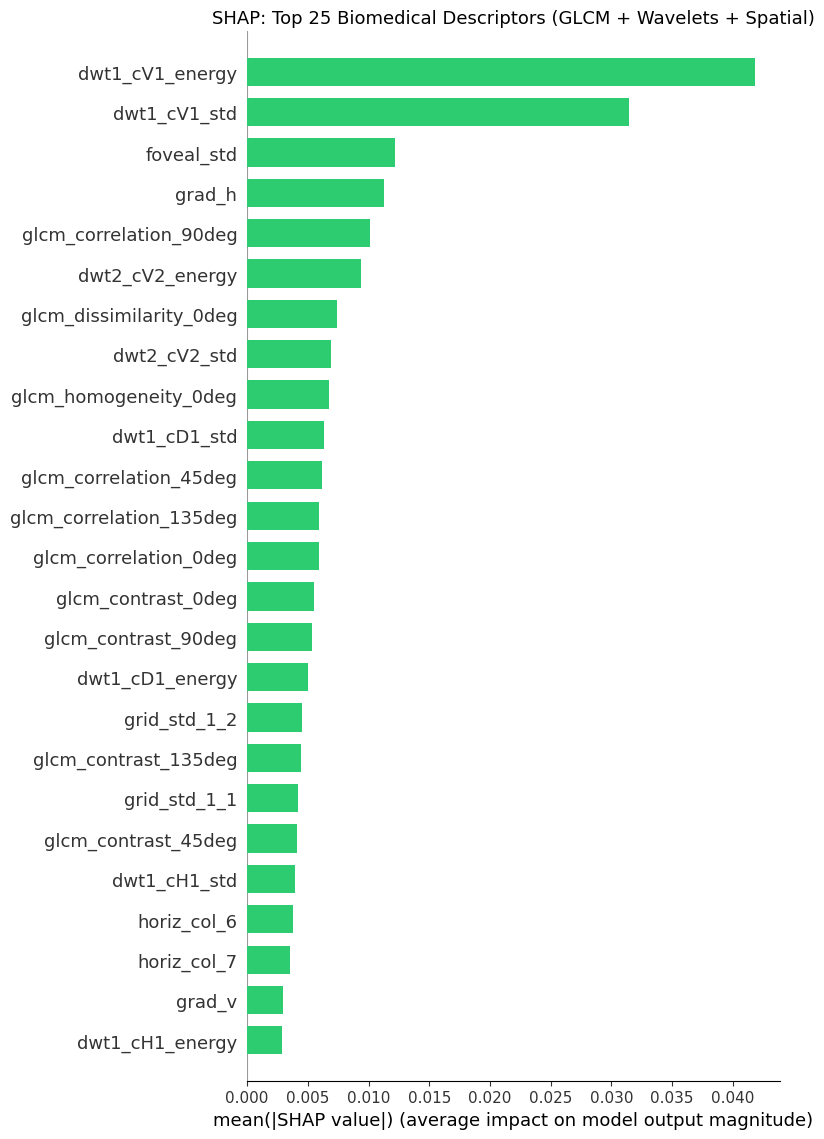

Saved SHAP summary to shap_summary_110.png


In [11]:
# ── SHAP Feature Importance on 110 Descriptors ───────────────────────────

print("Computing SHAP values on 110 features using RandomForest TreeExplainer...")
t0 = time.time()
rf_110 = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_110.fit(X_train_110, y_train)

explainer_110 = shap.TreeExplainer(rf_110)
shap_values_110 = explainer_110.shap_values(X_test_110)
print(f"SHAP analysis complete in {time.time()-t0:.1f}s")

if isinstance(shap_values_110, list):
    shap_abs_110 = np.mean([np.abs(sv) for sv in shap_values_110], axis=0)
elif isinstance(shap_values_110, np.ndarray) and shap_values_110.ndim == 3:
    shap_abs_110 = np.mean(np.abs(shap_values_110), axis=2)
else:
    shap_abs_110 = np.abs(shap_values_110)

plt.figure(figsize=(11, 8))
shap.summary_plot(shap_abs_110, X_test_110, feature_names=FEATURE_NAMES_110,
                  max_display=25, plot_type='bar', show=False, color='#2ecc71')
plt.title("SHAP: Top 25 Biomedical Descriptors (GLCM + Wavelets + Spatial)", fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_110.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved SHAP summary to shap_summary_110.png")


In [12]:
# ── Final Consolidated Benchmark Matrix ───────────────────────────────────

df_v4 = pd.DataFrame(results_records)
df_v4_test = df_v4[df_v4['Split'] == 'Test'].drop(columns=['Split']).sort_values('Macro ROC AUC', ascending=False).reset_index(drop=True)

fmt = {
    'Top-1 Accuracy': '{:.4f}', 'Top-2 Accuracy': '{:.4f}',
    'Balanced Acc': '{:.4f}', 'Macro F1': '{:.4f}',
    'Macro Precision': '{:.4f}', 'Macro Recall': '{:.4f}',
    'Log Loss': '{:.4f}', 'Macro ROC AUC': '{:.4f}'
}

display(df_v4_test.style.format(fmt).highlight_max(
    subset=['Top-1 Accuracy', 'Top-2 Accuracy', 'Balanced Acc', 'Macro F1', 'Macro ROC AUC'],
    color='#d4edda').highlight_min(subset=['Log Loss'], color='#d4edda').set_caption("Phase 3 Advanced Model Benchmark — Ranked by Macro ROC AUC"))


,Model,Top-1 Accuracy,Top-2 Accuracy,Balanced Acc,Macro F1,Macro Precision,Macro Recall,Log Loss,Macro ROC AUC
0,P2-Design 2E+TTA: SE_ResidualCNN4 (v4 + TTA n=5),0.8330,0.9760,0.8330,0.8294,0.8341,0.8330,0.4856,0.9681
1,P2-Design 2E: SE_ResidualCNN4 (no TTA),0.8230,0.9770,0.8230,0.8193,0.8268,0.8230,0.4869,0.9681
2,P1-Design 1G: HistGradientBoosting (110 Features),0.6100,0.8430,0.6100,0.5436,0.7071,0.6100,0.9588,0.8987
3,P1-Design 1F: XGBoost GPU (110 Features),0.6180,0.8490,0.6180,0.5511,0.7249,0.6180,0.9625,0.8980
